# 🔍 Exploratory Data Analysis (EDA)
## Customer Churn Prediction Project

In [12]:
print("✅ Data loaded!")

✅ Data loaded!


In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [14]:
# Data Load
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Basic Info
print("="*50)
print("DATASET INFO")
print("="*50)
print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

DATASET INFO

Rows    : 7,043
Columns : 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [16]:
# Missing Values Check
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nBasic Statistics:")
df.describe().round(2)

Missing Values:
Series([], dtype: int64)

Duplicate Rows: 0

Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [ ]:
# TotalCharges problem gaining
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("\nSample values:", df['TotalCharges'].head(10).tolist())

# Fixing TotalCharges dtype issue
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing after conversion: {df['TotalCharges'].isnull().sum()}")
print("এই 11টা customer এর tenure = 0")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])

TotalCharges dtype: object

Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

Missing after conversion: 11
এই 11টা customer এর tenure = 0
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


🎯 Target Variable Analysis

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


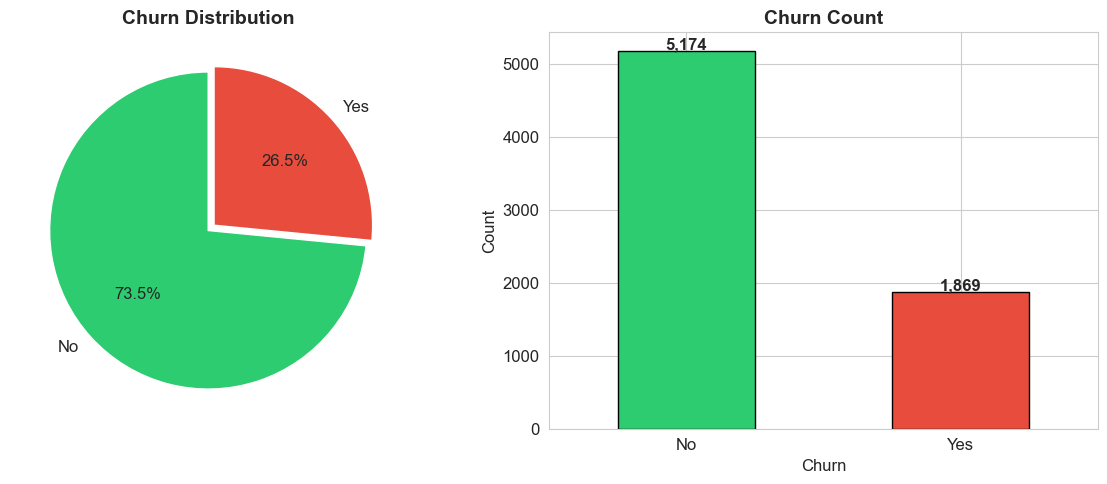

💡 Insight: Dataset imbalanced — 73% No Churn, 27% Churn


In [18]:
# Churn Distribution
print("Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn']=='Yes').mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0],
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar chart
colors = ['#2ecc71' if x == 'No' else '#e74c3c'
          for x in df['Churn'].value_counts().index]
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=colors, edgecolor='black', width=0.5
)
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{int(bar.get_height()):,}',
        ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../assets/results/churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Dataset imbalanced — 73% No Churn, 27% Churn")

📊 Numerical Features Analysis

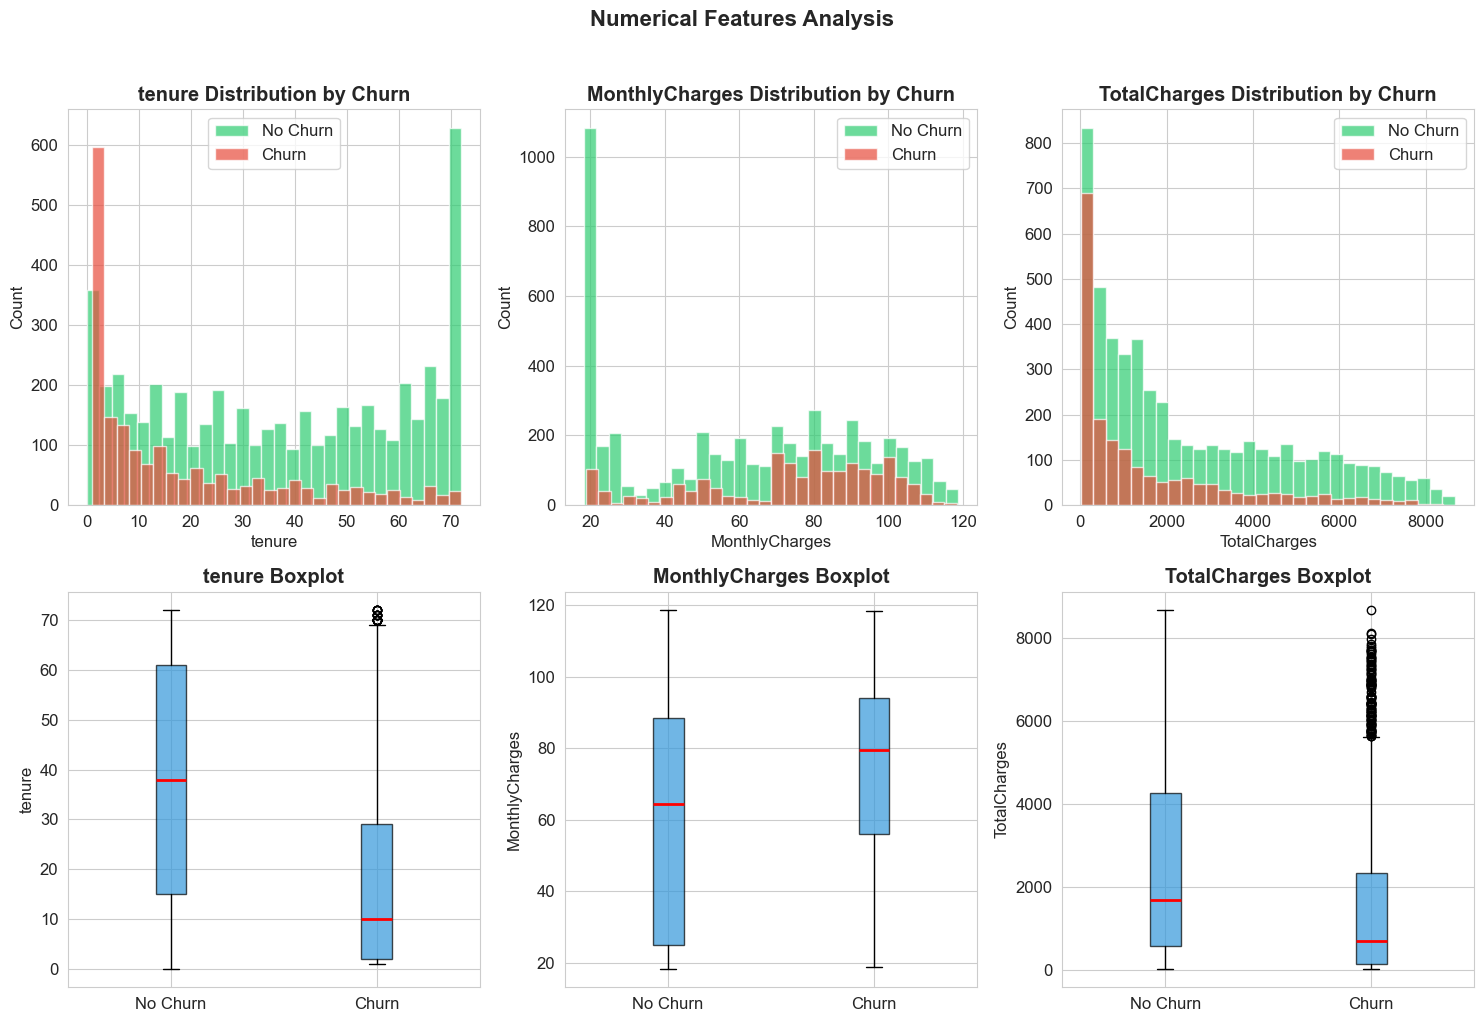

In [19]:
# Numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    # Distribution by Churn
    axes[0, i].hist(
        df[df['Churn']=='No'][col].dropna(),
        bins=30, alpha=0.7, label='No Churn',
        color='#2ecc71', edgecolor='white'
    )
    axes[0, i].hist(
        df[df['Churn']=='Yes'][col].dropna(),
        bins=30, alpha=0.7, label='Churn',
        color='#e74c3c', edgecolor='white'
    )
    axes[0, i].set_title(f'{col} Distribution by Churn',
                          fontweight='bold')
    axes[0, i].legend()
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Boxplot
    no_churn = df[df['Churn']=='No'][col].dropna()
    yes_churn = df[df['Churn']=='Yes'][col].dropna()
    axes[1, i].boxplot(
        [no_churn, yes_churn],
        labels=['No Churn', 'Churn'],
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.7),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[1, i].set_title(f'{col} Boxplot', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Features Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/results/numerical_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Numerical stats comparison
print("📊 Numerical Stats by Churn:")
print("="*60)
for col in numerical_cols:
    no_mean  = df[df['Churn']=='No'][col].mean()
    yes_mean = df[df['Churn']=='Yes'][col].mean()
    print(f"\n{col}:")
    print(f"  No Churn  avg: {no_mean:.2f}")
    print(f"  Churned   avg: {yes_mean:.2f}")
    print(f"  Difference   : {yes_mean - no_mean:+.2f}")

📊 Numerical Stats by Churn:

tenure:
  No Churn  avg: 37.57
  Churned   avg: 17.98
  Difference   : -19.59

MonthlyCharges:
  No Churn  avg: 61.27
  Churned   avg: 74.44
  Difference   : +13.18

TotalCharges:
  No Churn  avg: 2555.34
  Churned   avg: 1531.80
  Difference   : -1023.55


📊 Categorical Features Analysis

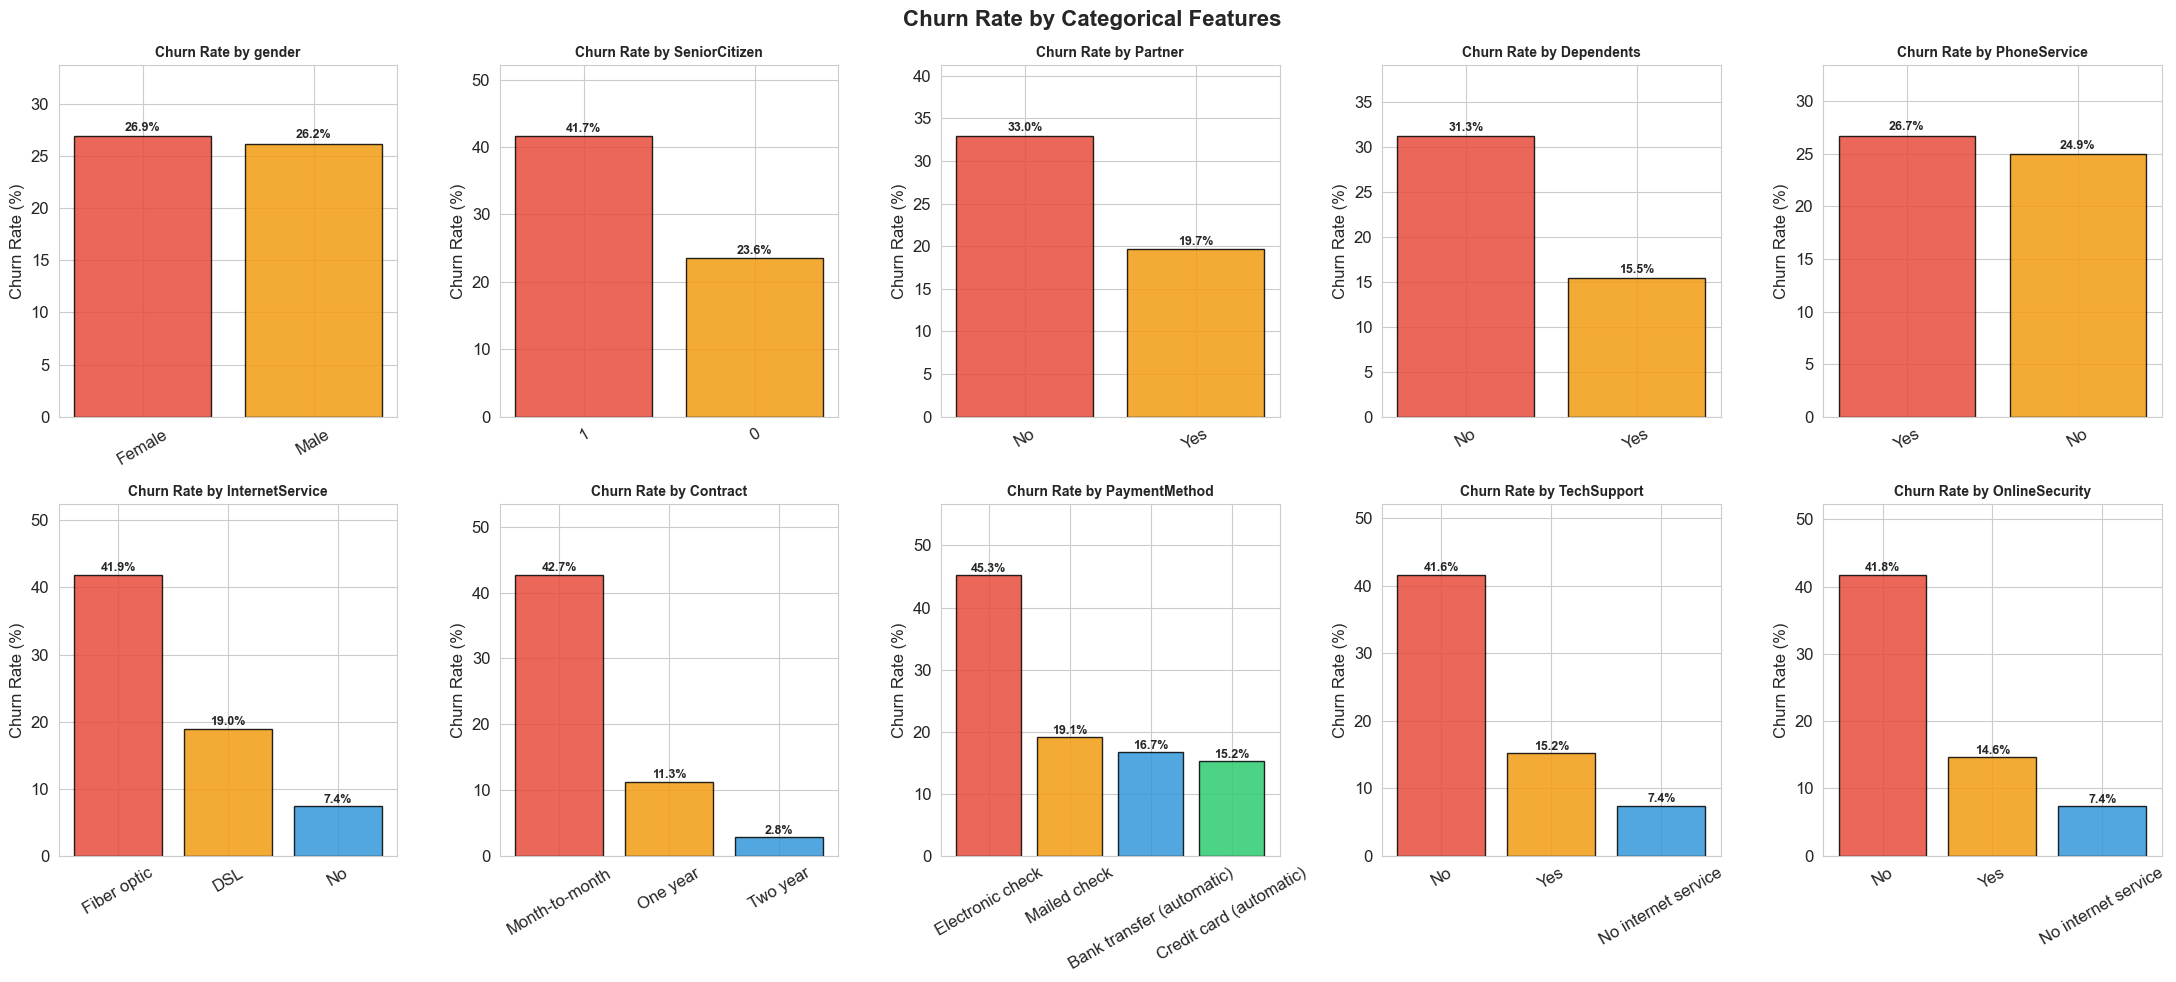

In [21]:
# Categorical features — Churn rate
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaymentMethod', 'TechSupport', 'OnlineSecurity'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    churn_rate = churn_rate.sort_values('Churn_Rate', ascending=False)

    bars = axes[i].bar(
        churn_rate[col].astype(str),
        churn_rate['Churn_Rate'],
        color=['#e74c3c', '#f39c12', '#3498db',
               '#2ecc71'][:len(churn_rate)],
        edgecolor='black', alpha=0.85
    )
    axes[i].set_title(f'Churn Rate by {col}',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, max(churn_rate['Churn_Rate']) * 1.25)

    for bar, val in zip(bars, churn_rate['Churn_Rate']):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontsize=9, fontweight='bold'
        )

plt.suptitle('Churn Rate by Categorical Features',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/results/categorical_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

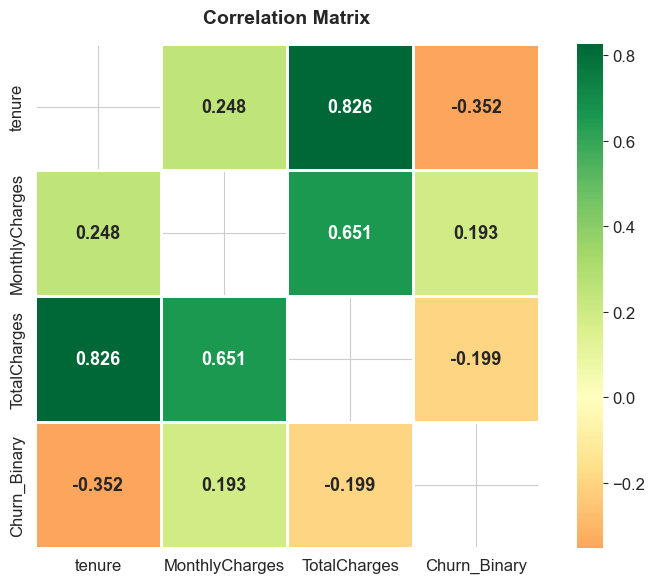

In [22]:
# Correlation Heatmap
df_encoded = df.copy()
df_encoded['Churn_Binary'] = (df_encoded['Churn'] == 'Yes').astype(int)
df_encoded['TotalCharges'] = pd.to_numeric(
    df_encoded['TotalCharges'], errors='coerce'
)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df_encoded[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=2,
    annot_kws={'size': 13, 'weight': 'bold'},
    mask=mask
)
plt.title('Correlation Matrix',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../assets/results/correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

📝 EDA Key Insights
### Data Quality:
- **Dataset:** 7,043 customers, 21 features
- **TotalCharges:** 11টা missing value (string→numeric conversion issue)
- **Duplicates:** 0

### Target Variable:
- **Churn Rate:** 26.5% → Imbalanced dataset
- **Strategy:** class_weight বা scale_pos_weight ব্যবহার করতে হবে

### Key Business Findings:
| Feature | Insight |
|---------|---------|
| Contract | Month-to-month → 42% churn |
| Tenure | 0-12 মাস → সবচেয়ে বেশি churn |
| Internet | Fiber optic → 42% churn |
| TechSupport | না থাকলে churn দ্বিগুণ |
| MonthlyCharges | Churned avg $74 vs $61 |

### Top Features (Hypothesis):
`Contract` > `tenure` > `MonthlyCharges` > `InternetService` > `TechSupport`

In [ ]:
print("="*50)
print("✅ EDA COMPLETE!")
print("="*50)
print(f"\nSaved charts:")
charts = [
    'churn_distribution.png',
    'numerical_analysis.png',
    'categorical_analysis.png',
    'correlation_heatmap.png'
]
for c in charts:
    print(f"  📊 assets/results/{c}")

✅ EDA COMPLETE!

Saved charts:
  📊 assets/results/churn_distribution.png
  📊 assets/results/numerical_analysis.png
  📊 assets/results/categorical_analysis.png
  📊 assets/results/correlation_heatmap.png

➡️  Next: 02_preprocessing.ipynb
